In [1]:
%cd '/Users/voytek/GitHub/voytekresearch/spikeparam/'

/Users/voytek/GitHub/voytekresearch/spikeparam


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('../spikeparam/')

from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from neurodsp import spectral

from scipy import signal

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
# open and load the data
filedir = 'datasets/spe-1/EAP-Yes/c14/'

# load npx data
npx_path = filedir + 'c14_npx_raw.bin'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 161
npx_recording = np.memmap(npx_path, mode = 'r', dtype=np.int16, order = 'C')
npx_samples = int(len(npx_recording)/npx_channels)
npx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')
npx_recording = npx_recording[npx_patch_channel, :]
npx_recording = np.asarray(npx_recording)

npx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec


# filter the neuropixels data
npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)


np.save(filedir + 'npx_filt.npy', npx_filt)



In [ ]:
# # open and load the data
# filedir = 'datasets/spe-1/EAP-Yes/c14/'

# ######################
# # the below will need to be read from the csv
# ######################

# # load patch data
# patch_path = filedir + 'c14_patch_ch1.bin'
# patch_fs = 50023.88925263
# patch_one_ms = int(patch_fs / 1000)
# patch_recording = np.fromfile(patch_path, dtype='float64')
# patch_recording = np.asarray(patch_recording)
# patch_recording = -patch_recording # positive up

# # load npx data
# npx_path = filedir + 'c14_npx_raw.bin'
# npx_fs = 30000 # sampling rate
# npx_one_ms = int(npx_fs / 1000)
# npx_channels = 384
# npx_patch_channel = 160
# npx_recording = np.memmap(npx_path, mode = 'r', dtype=np.int16, order = 'C')
# npx_samples = int(len(npx_recording)/npx_channels)
# npx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')
# npx_recording = npx_recording[npx_patch_channel, :]
# npx_recording = np.asarray(npx_recording)

# # load LFP data
# lfp_path = filedir + 'c14_npx_lfp.bin'
# lfp_fs = 2500 # sampling rate
# lfp_one_ms = int(lfp_fs / 1000)
# lfp_recording = np.memmap(lfp_path, mode = 'r', dtype=np.int16, order = 'C')
# lfp_samples = int(len(lfp_recording)/npx_channels)
# lfp_recording = lfp_recording.reshape((lfp_samples, npx_channels), order = 'F')
# lfp_recording = lfp_recording[:, npx_patch_channel]
# lfp_recording = np.asarray(lfp_recording)
# lfp_recording = lfp_recording - np.mean(lfp_recording) # de-mean

# ##############
# patch_times = np.arange(0, np.shape(patch_recording)[0]) / patch_one_ms # in ms instead of sec
# npx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec
# lfp_times = np.arange(0, np.shape(lfp_recording)[0]) / lfp_one_ms # in ms instead of sec

# # filter the patch data
# patch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)
# # filter the neuropixels data
# npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)
# # filter the LFP data
# lfp_filt = butter_bandpass(lfp_recording, fs=lfp_fs, filt_freq=[0.1, 250], order=4)

# np.save(filedir + 'patch_filt.npy', patch_filt)
# np.save(filedir + 'npx_filt.npy', npx_filt)
# np.save(filedir + 'lfp_filt.npy', lfp_filt)


In [5]:
# open and load the data
filedir = 'datasets/spe-1/EAP-Yes/c14/'

patch_filt = np.load(filedir + 'patch_filt.npy')
npx_filt = np.load(filedir + 'npx_filt.npy')
lfp_filt = np.load(filedir + 'lfp_filt.npy')

patch_fs = 50023.88925263
patch_one_ms = int(patch_fs / 1000)

npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)

lfp_fs = 2500 # sampling rate
lfp_one_ms = int(lfp_fs / 1000)

patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec
npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec


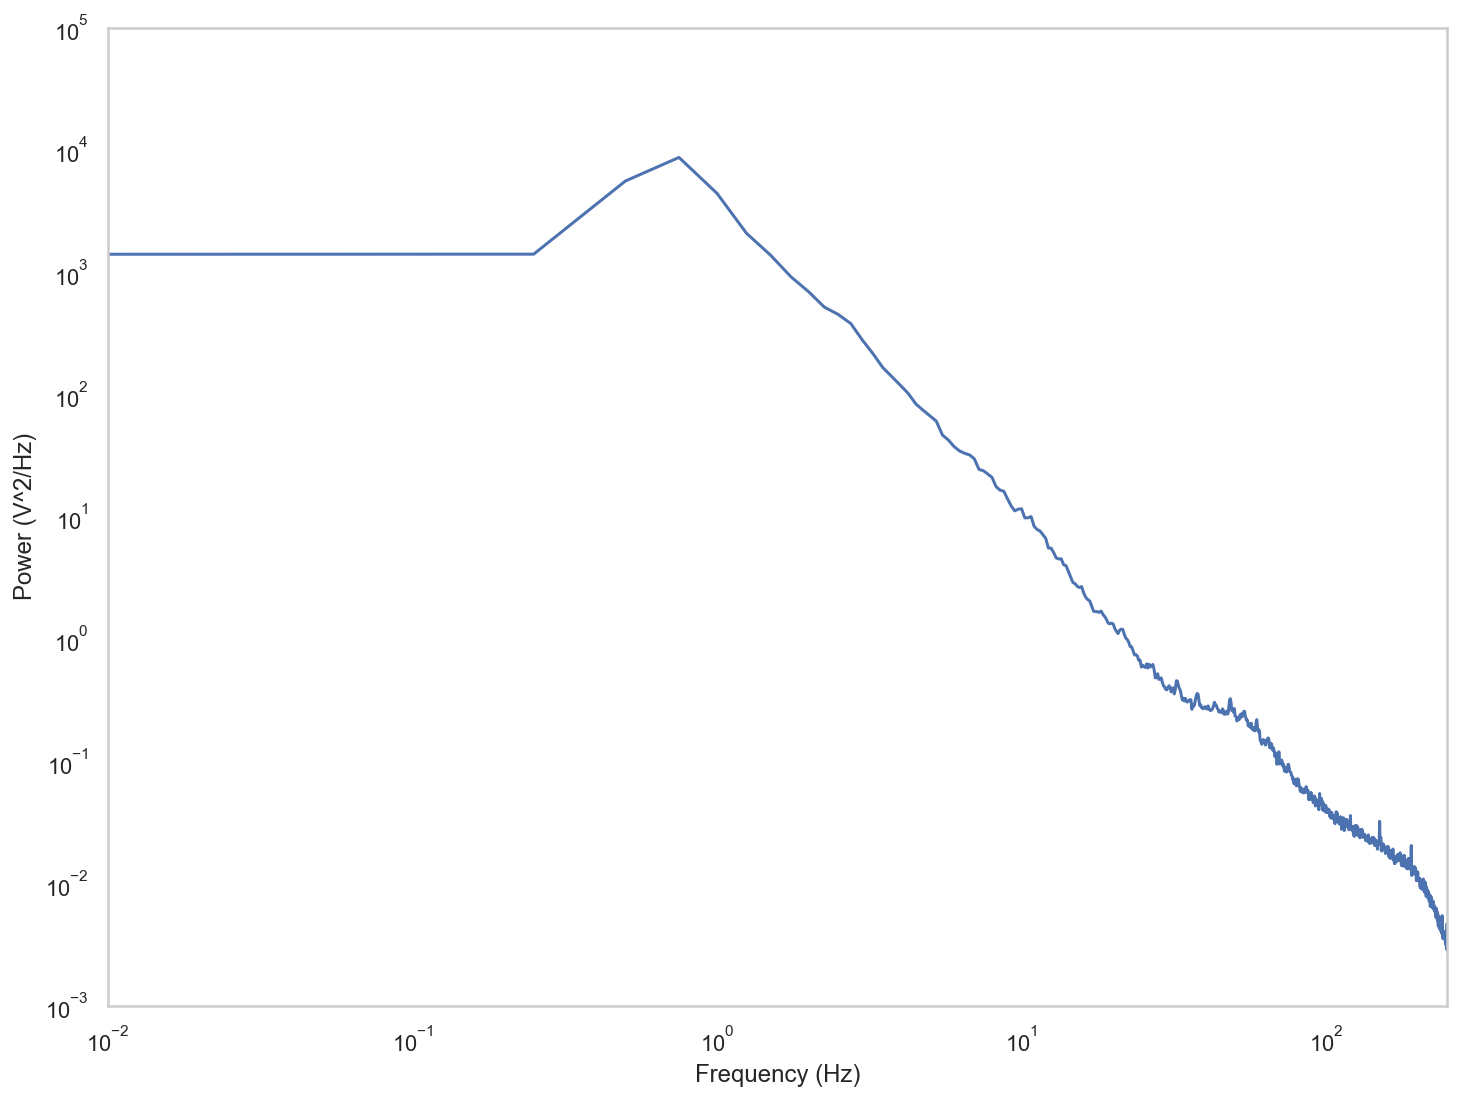

In [19]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()

In [7]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

sp = Spike(thresh_amp=250., window_length=(5., 5.), smooth_frac=.01)

sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

  0%|          | 0/5421 [00:00<?, ?it/s]

In [8]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

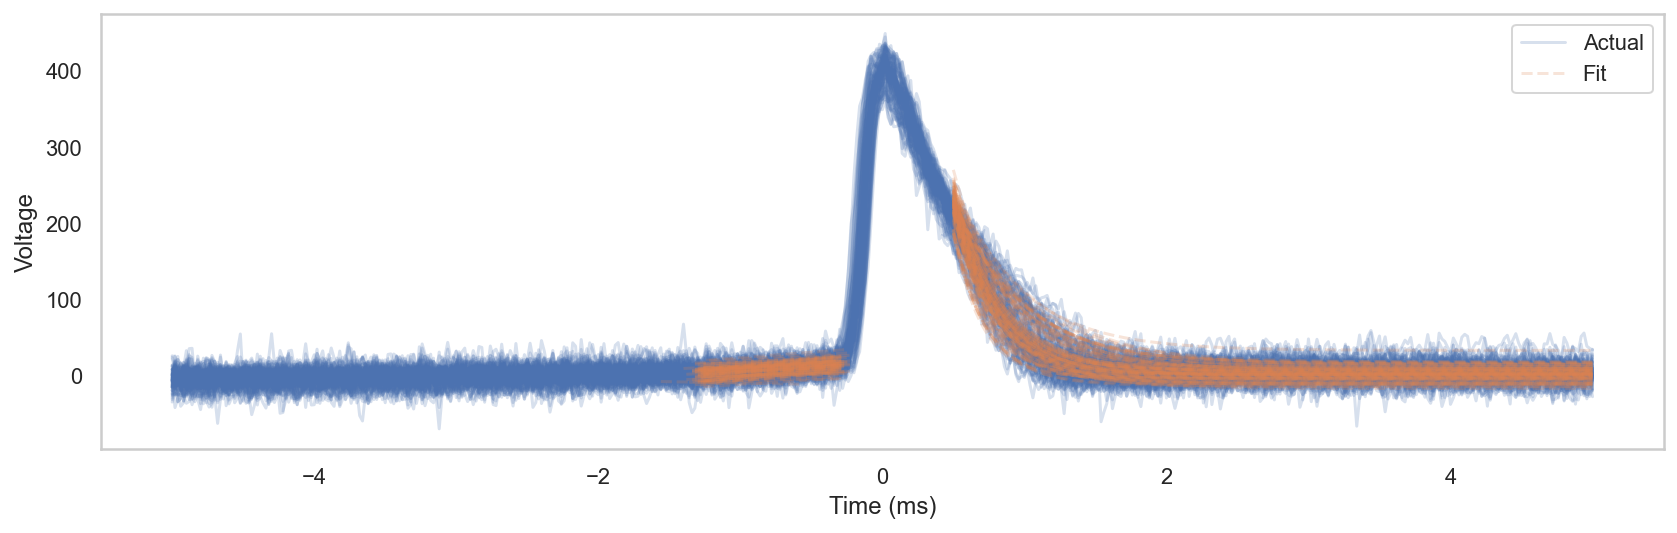

In [9]:
# First 100 fits
sp.plot(inds=np.arange(100))

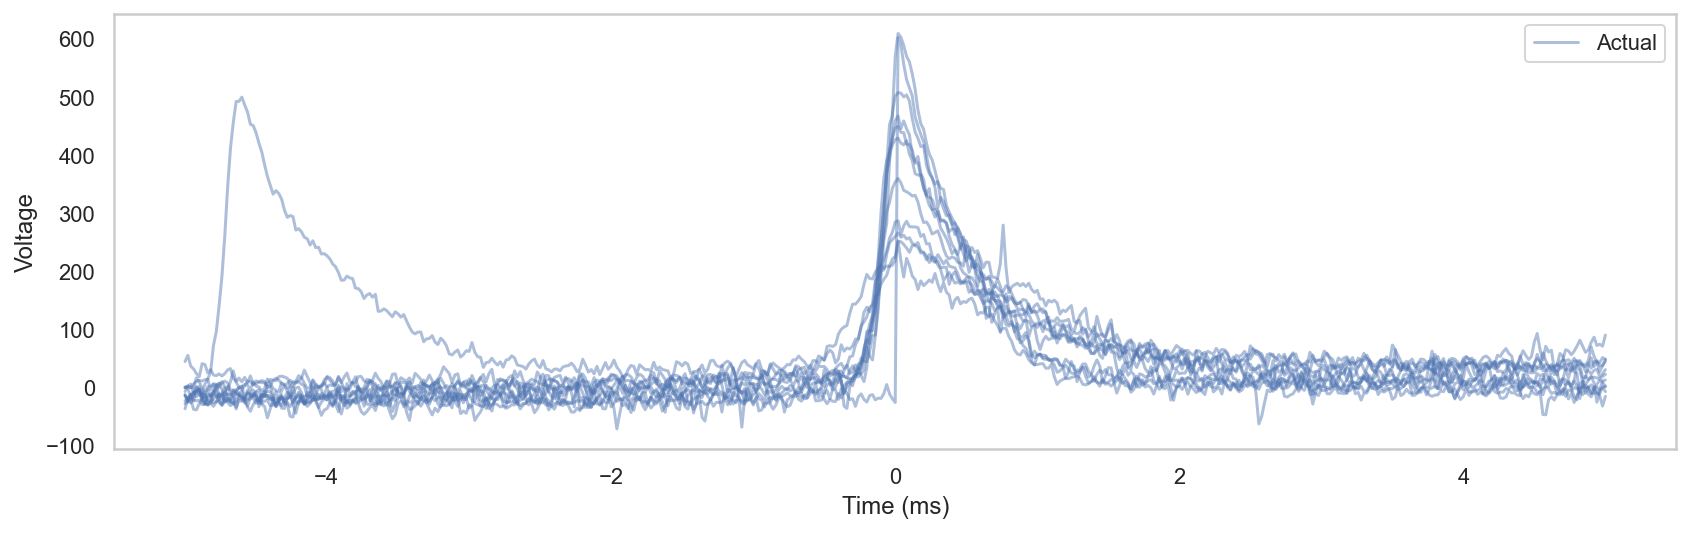

In [10]:
# Spikes with failed fits (.1% of all fits)
sp.plot(inds=sp.inds_error)

In [11]:
sp.df_features

,voltage_ramp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,stim_mean,stim_std
0,10.278641,0.26,14.690331,395.951571,0.60,79.815825,3.948222,-7.969191,10.774852,0.092422,0.931976,-172.865921,11.160898
1,9.784120,0.26,32.370545,367.470405,0.76,49.173609,2.080798,16.163271,92.495807,0.096889,0.950345,-187.282045,5.132214
2,11.852871,0.26,22.097916,410.769602,0.58,38.602203,3.252342,10.962798,150.208233,0.109745,0.931059,-191.690628,6.374541
3,18.679989,0.26,-16.844063,380.923225,0.66,104.931506,2.765642,-9.252601,31.025177,0.203775,0.951483,-151.312047,2.646092
4,21.063744,0.28,-19.574062,386.861868,0.72,51.946930,2.844247,16.399736,959.521555,0.305516,0.940651,-149.501108,2.785110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5416,20.984191,0.24,8.603307,579.864877,0.52,203.968515,1.435538,18.259446,56.153171,0.390204,0.983333,-139.905337,5.783354
5417,3.254297,0.26,27.544328,539.096322,0.48,182.731743,2.330059,27.294305,95.194517,0.015524,0.970840,-184.885744,7.738895
5418,22.268215,0.20,30.089604,642.778498,0.46,256.968136,1.976378,15.565056,50.815721,0.461483,0.984444,-121.463236,4.447857
5419,16.170690,0.20,19.156683,599.141599,0.46,239.975432,1.980195,14.101781,394.631451,0.263415,0.982903,-158.174448,4.726071


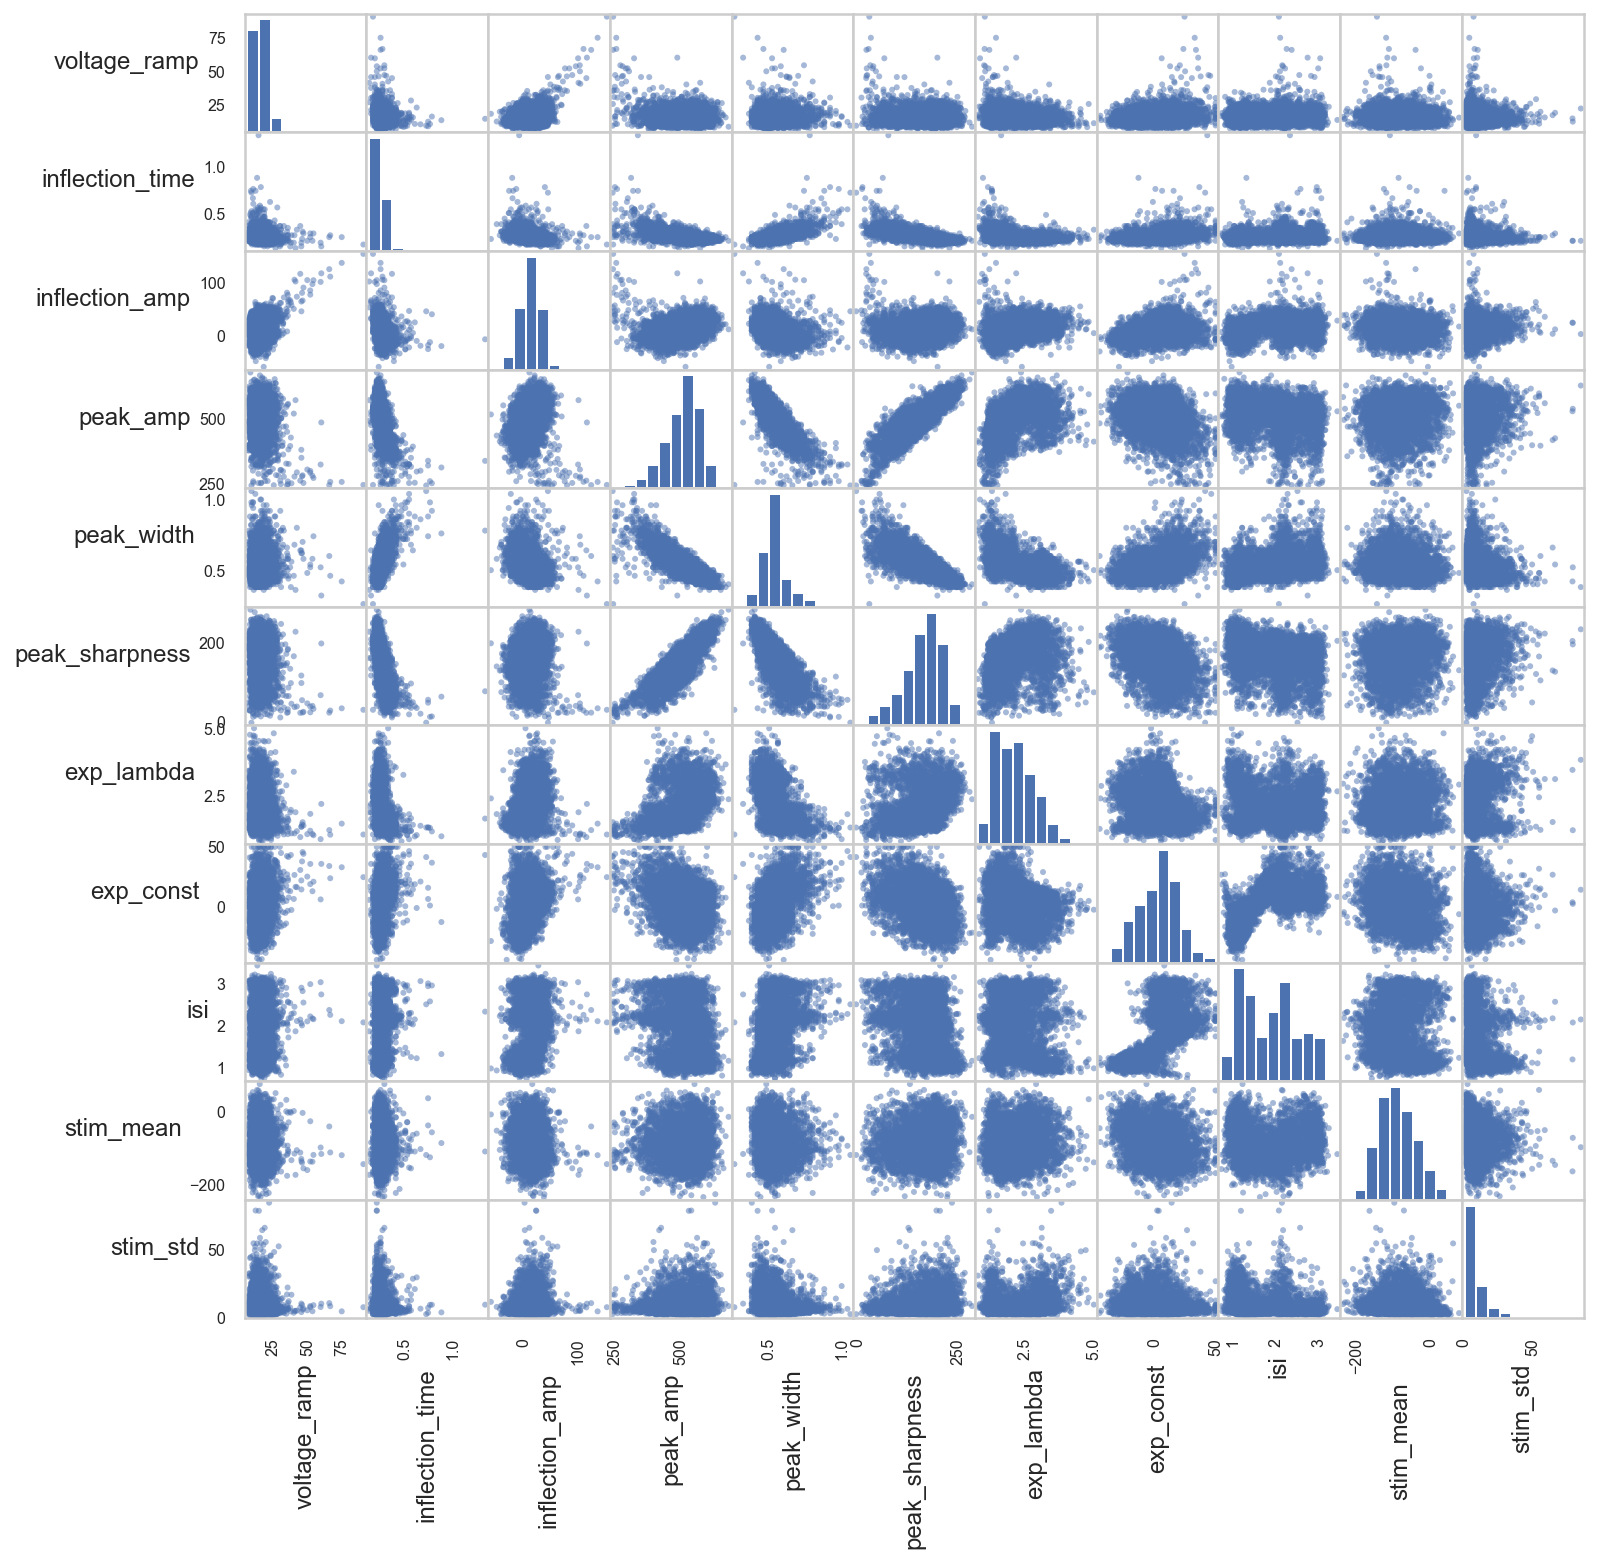

In [12]:
# Ensure inflection times are between 0 and 2 ms
df_drop = sp.df_features.loc[sp.df_features['inflection_time'] > 0.]
df_drop = df_drop.loc[df_drop['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop = df_drop.loc[df_drop['r_squared_exp']  >= .5]
df_drop = df_drop.loc[df_drop['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop[['isi']] = np.log10(df_drop[['isi']])

# drop no-longer-used QC features
df_drop = df_drop.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

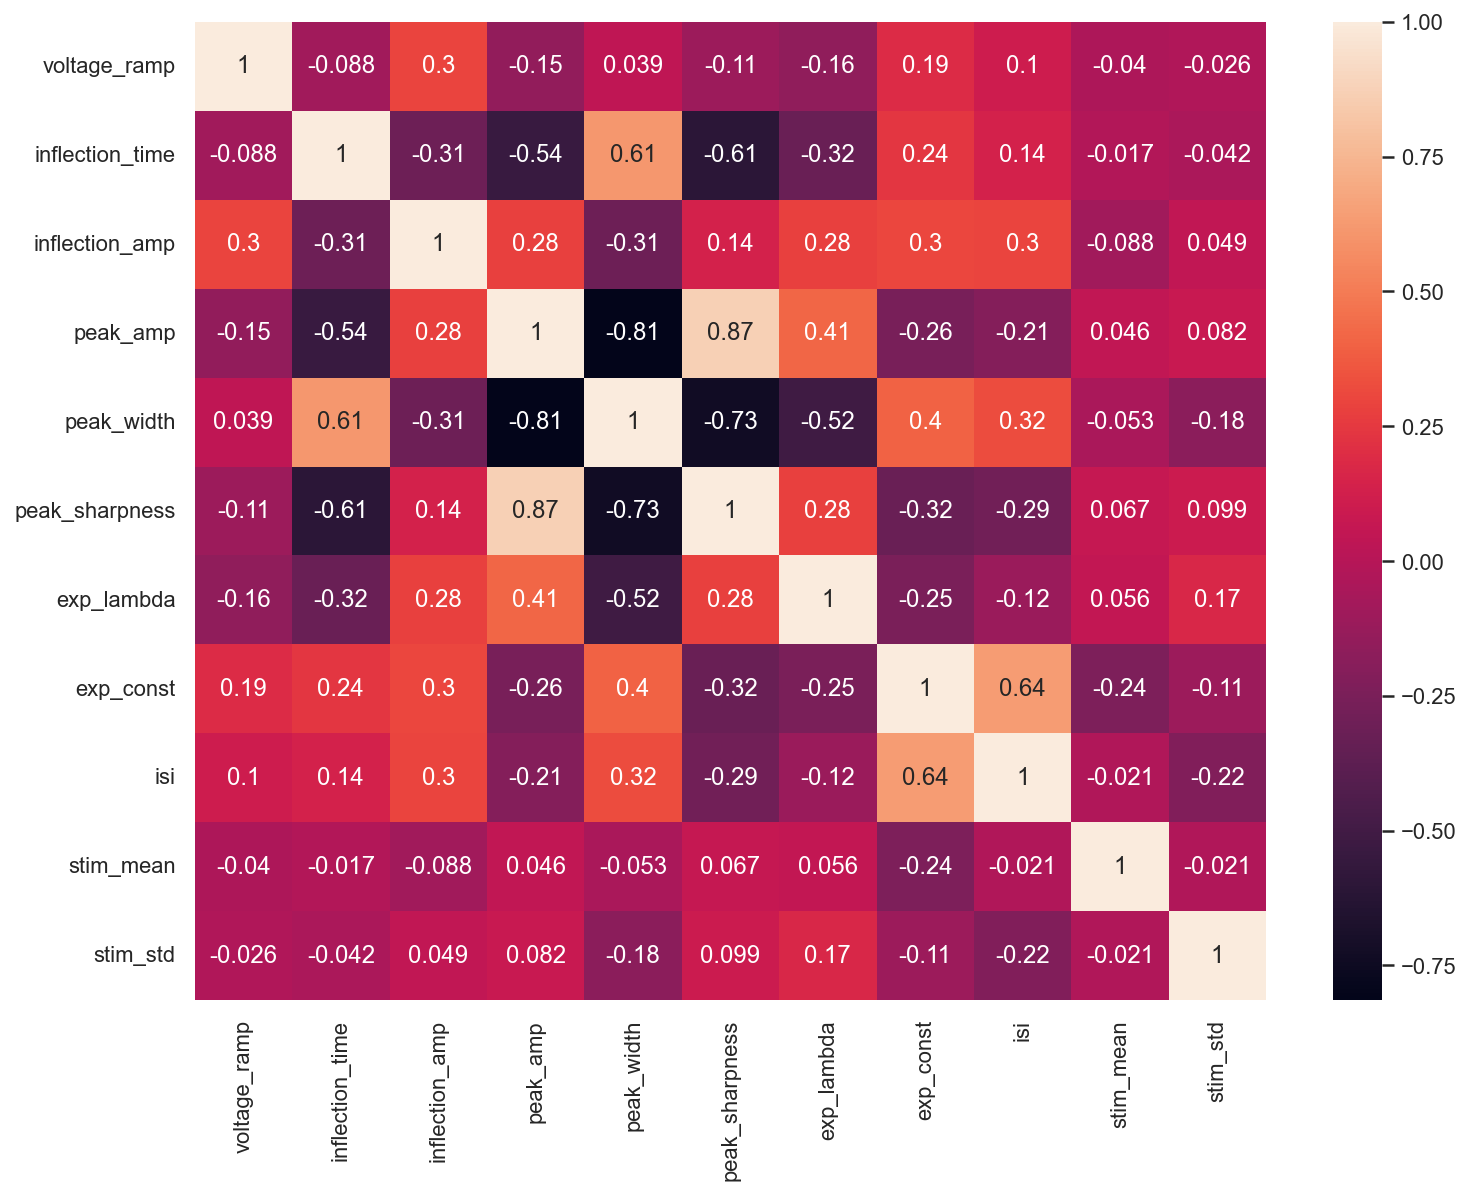

,voltage_ramp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,stim_mean,stim_std
voltage_ramp,1.0***,-0.09***,0.3***,-0.15***,0.04**,-0.11***,-0.16***,0.19***,0.1***,-0.04**,-0.03
inflection_time,-0.09***,1.0***,-0.31***,-0.54***,0.61***,-0.61***,-0.32***,0.24***,0.14***,-0.02,-0.04**
inflection_amp,0.3***,-0.31***,1.0***,0.28***,-0.31***,0.14***,0.28***,0.3***,0.3***,-0.09***,0.05***
peak_amp,-0.15***,-0.54***,0.28***,1.0***,-0.81***,0.87***,0.41***,-0.26***,-0.21***,0.05**,0.08***
peak_width,0.04**,0.61***,-0.31***,-0.81***,1.0***,-0.73***,-0.52***,0.4***,0.32***,-0.05***,-0.18***
peak_sharpness,-0.11***,-0.61***,0.14***,0.87***,-0.73***,1.0***,0.28***,-0.32***,-0.29***,0.07***,0.1***
exp_lambda,-0.16***,-0.32***,0.28***,0.41***,-0.52***,0.28***,1.0***,-0.25***,-0.12***,0.06***,0.17***
exp_const,0.19***,0.24***,0.3***,-0.26***,0.4***,-0.32***,-0.25***,1.0***,0.64***,-0.24***,-0.11***
isi,0.1***,0.14***,0.3***,-0.21***,0.32***,-0.29***,-0.12***,0.64***,1.0***,-0.02,-0.22***
stim_mean,-0.04**,-0.02,-0.09***,0.05**,-0.05***,0.07***,0.06***,-0.24***,-0.02,1.0***,-0.02


In [13]:
spikes_corr = df_drop.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_drop.corr()
pval = df_drop.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [18]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf


mod = ols(formula="isi ~ voltage_ramp + inflection_time + \
    inflection_amp + peak_width + peak_amp + peak_sharpness + exp_lambda + exp_const + \
    stim_mean + stim_std", data=df_drop)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                    isi   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     439.3
Date:                Tue, 15 Nov 2022   Prob (F-statistic):               0.00
Time:                        11:18:32   Log-Likelihood:                -2910.6
No. Observations:                4630   AIC:                             5843.
Df Residuals:                    4619   BIC:                             5914.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.3509      0.185     